#Freelancer Data Analysis and visualization

#INTRODUCTION

This project focuses on analyzing a freelancer dataset using Python, Pandas, and data visualization techniques. The purpose of this analysis is to understand freelancer characteristics, earnings, experience, platforms, skills, and other factors.

# Dataset Information

- Total Rows: 6,000
- Total Columns: 36
- Dataset Type: Freelancer Data
- Main Focus: Freelancer profiles, skills, experience, platforms, and monthly earnings

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [47]:
mk=pd.read_csv('/content/drive/MyDrive/pk_freelancing_economy_2015_2025.csv')
print(mk)

     freelancer_id  year quarter            city  gender   age  \
0      PK-FL-00001  2022      Q3      Rawalpindi    Male  21.0   
1      PK-FL-00002  2025      Q4        Peshawar    Male  18.0   
2      PK-FL-00003  2020      Q2       Hyderabad    Male  44.0   
3      PK-FL-00004  2019      Q2        Peshawar    Male  31.0   
4      PK-FL-00005  2021      Q3      Gujranwala  Female  36.0   
...            ...   ...     ...             ...     ...   ...   
5995   PK-FL-05996  2024      Q1          Lahore    Male  39.0   
5996   PK-FL-05997  2020      Q1  Rahim Yar Khan    Male  22.0   
5997   PK-FL-05998  2023      Q2      Gujranwala    Male  30.0   
5998   PK-FL-05999  2024      Q4         Karachi    Male  36.0   
5999   PK-FL-06000  2019      Q4          Lahore    Male  22.0   

      age_missing_flag               education_level  edu_missing_flag  \
0                    0                    Bachelor's                 1   
1                    0                    Bachelor's       

In [48]:
mk.shape

(6000, 36)

In [49]:
mk.head()

,freelancer_id,year,quarter,city,gender,age,age_missing_flag,education_level,edu_missing_flag,english_proficiency,...,jobs_completed,review_score,review_missing_flag,job_success_score_pct,jss_missing_flag,repeat_client_rate_pct,repeat_missing_flag,primary_client_region,payment_method,freelancing_as_primary_income
0,PK-FL-00001,2022,Q3,Rawalpindi,Male,21.0,0,Bachelor's,1,Basic,...,189,4.7,0,96.0,0,61.0,0,USA,Payoneer + Skrill,No - Side Income
1,PK-FL-00002,2025,Q4,Peshawar,Male,18.0,0,Bachelor's,0,Conversational,...,42,4.4,0,NaN,1,50.0,0,Canada,JazzCash/Easypaisa,Yes
2,PK-FL-00003,2020,Q2,Hyderabad,Male,44.0,0,Master's,0,Native/Bilingual,...,58,5.0,0,NaN,1,15.0,0,Canada,Wise,No - Side Income
3,PK-FL-00004,2019,Q2,Peshawar,Male,31.0,0,Bachelor's,0,Fluent,...,216,4.9,0,93.0,0,51.0,0,USA,Wise,Yes
4,PK-FL-00005,2021,Q3,Gujranwala,Female,36.0,0,Self-taught/No Formal Degree,0,Native/Bilingual,...,45,4.9,0,77.0,0,36.0,0,Australia,Wise,Yes


#Data cleaning

In [50]:
mk.isnull().sum()

,0
freelancer_id,0
year,0
quarter,0
city,0
gender,0
age,0
age_missing_flag,0
education_level,0
edu_missing_flag,0
english_proficiency,0


In [125]:
mk['review_score']=mk['review_score'].fillna(mk['review_score'].mean())

In [126]:
mk['review_score'].isnull().sum()

np.int64(0)

In [127]:
mk['job_success_score_pct']=mk['job_success_score_pct'].fillna(mk['job_success_score_pct'].mean())

In [128]:
mk['job_success_score_pct'].isnull().sum()

np.int64(0)

In [129]:
mk.duplicated().sum()

np.int64(0)

In [137]:
mk.isnull().sum()

,0
freelancer_id,0
year,0
quarter,0
city,0
gender,0
age,0
age_missing_flag,0
education_level,0
edu_missing_flag,0
english_proficiency,0


In [138]:
mk.duplicated().sum()

np.int64(0)

## Data Analysis

In [67]:
mk["monthly_earnings_usd"].mean()

np.float64(1717.8826666666666)

In [68]:
mk["monthly_earnings_usd"].median()

1180.0

In [69]:
mk["monthly_earnings_usd"].min(), mk["monthly_earnings_usd"].max()

(16.0, 19252.0)

In [70]:
mk["experience_group"] = pd.cut(
    mk["experience_years"],
    bins=[0, 1, 3, 5, 10, 11],
    labels=["0-1 years", "1-3 years", "3-5 years", "5-10 years", "10+ years"]
)

In [71]:
mk.groupby("experience_group")["monthly_earnings_usd"].mean()

/tmp/ipykernel_568/426116788.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mk.groupby("experience_group")["monthly_earnings_usd"].mean()


,monthly_earnings_usd
experience_group,
0-1 years,1597.597545
1-3 years,1658.870956
3-5 years,1832.659330
5-10 years,2090.042345
10+ years,1892.818182


<Axes: title={'center': 'Average Monthly Earnings by Experience'}, xlabel='Experience Group', ylabel='Monthly Earnings (USD)'>

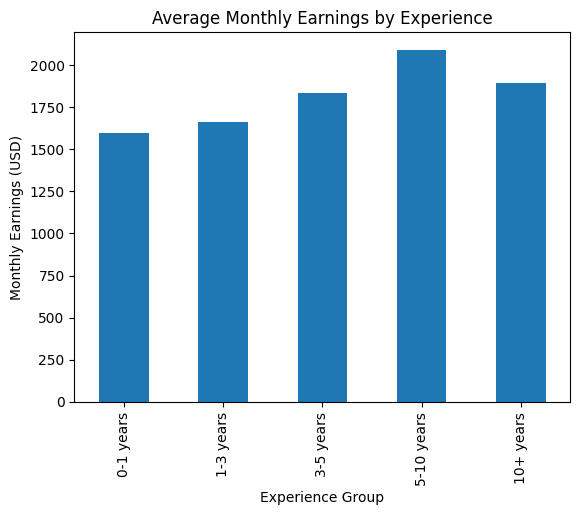

In [72]:
mk.groupby("experience_group", observed=True)["monthly_earnings_usd"].mean().plot(
    kind="bar",
    title="Average Monthly Earnings by Experience",
    xlabel="Experience Group",
    ylabel="Monthly Earnings (USD)"
)

In [73]:
mk.groupby("platform")["monthly_earnings_usd"].mean()

,monthly_earnings_usd
platform,
Fiverr,1518.131455
Freelancer.com,1706.506527
Upwork,1909.704147


Text(0.5, 0, '(Platform)')

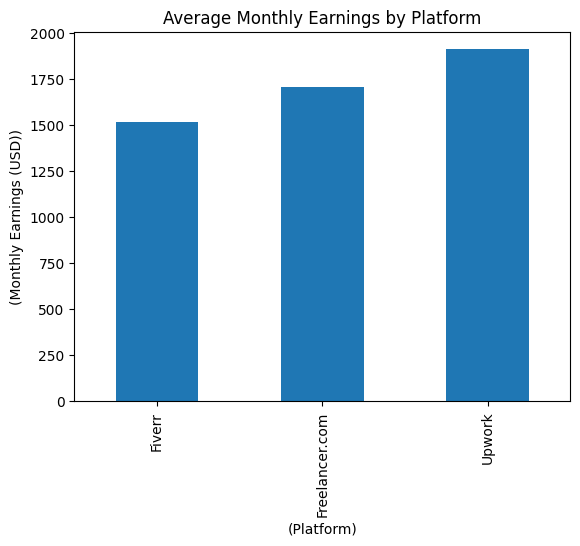

In [74]:
mk.groupby("platform")["monthly_earnings_usd"].mean().plot.bar()
plt.title("Average Monthly Earnings by Platform")
plt.ylabel('(Monthly Earnings (USD))')
plt.xlabel('(Platform)')

In [75]:
mk.groupby("education_level")["monthly_earnings_usd"].mean()

,monthly_earnings_usd
education_level,
Bachelor's,1687.455718
Intermediate/A-Levels,1759.091057
Master's,1840.757056
Matric/O-Levels,1637.810127
PhD/MPhil,1713.745614
Self-taught/No Formal Degree,1683.367121


<Axes: title={'center': 'Average Monthly Earnings by Education Level'}, xlabel='Education Level', ylabel='Monthly Earnings (USD)'>

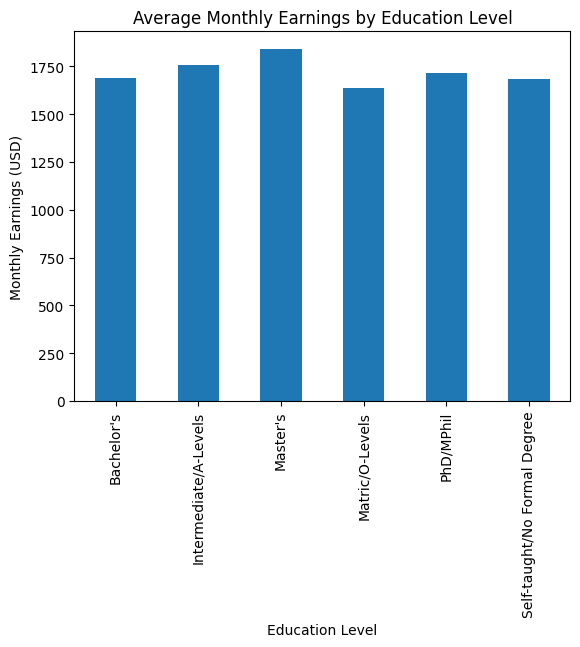

In [76]:
mk.groupby("education_level")["monthly_earnings_usd"].mean().plot(
kind='bar',
title='Average Monthly Earnings by Education Level',
xlabel="Education Level",
ylabel="Monthly Earnings (USD)"
)


In [77]:
mk.groupby('gender')['monthly_earnings_usd'].mean()

,monthly_earnings_usd
gender,
Female,1731.378039
Male,1714.241058


<Axes: title={'center': 'Average Monthly Earnings by Gender'}, xlabel='Gender', ylabel='Monthly Earnings (USD)'>

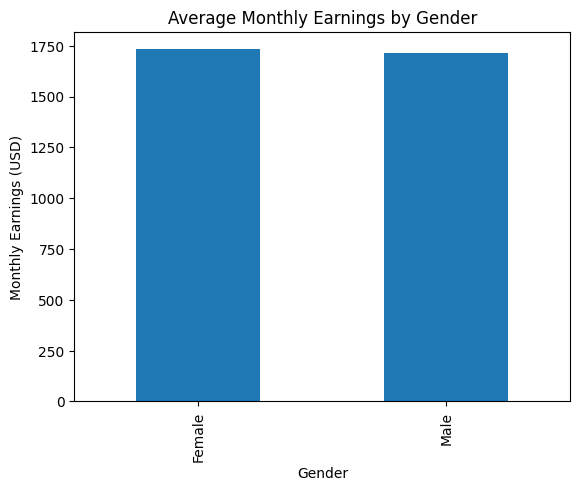

In [78]:
mk.groupby('gender')['monthly_earnings_usd'].mean().plot(
kind='bar',
title='Average Monthly Earnings by Gender',
xlabel='Gender',
ylabel='Monthly Earnings (USD)'
)

In [79]:
mk.groupby("english_proficiency")["monthly_earnings_usd"].mean()

,monthly_earnings_usd
english_proficiency,
Basic,1711.918728
Conversational,1742.223881
Fluent,1742.561854
Native/Bilingual,1595.839910


<Axes: title={'center': 'Average Monthly Earnings by English Proficiency'}, xlabel='English Proficiency', ylabel='Monthly Earnings (USD)'>

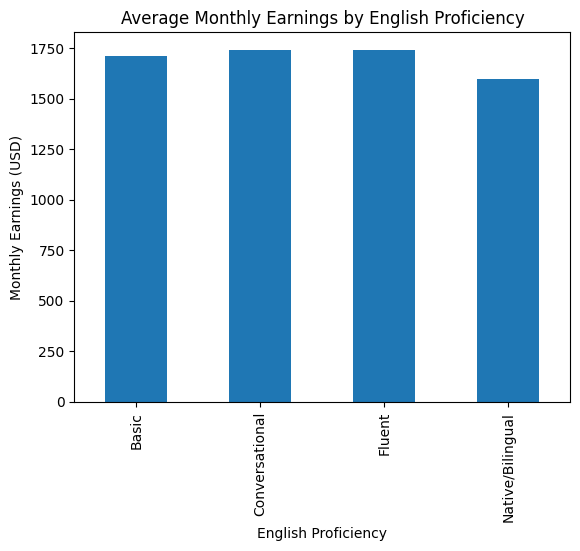

In [80]:
mk.groupby("english_proficiency")["monthly_earnings_usd"].mean().plot(
    kind="bar",
    title="Average Monthly Earnings by English Proficiency",
    xlabel="English Proficiency",
    ylabel="Monthly Earnings (USD)"
)

In [81]:
mk.groupby("skill_category")["monthly_earnings_usd"].mean()

,monthly_earnings_usd
skill_category,
AI & Machine Learning,2924.698492
Accounting & Finance,1488.262799
Content Writing,893.471698
Cybersecurity,3242.146067
Data Entry & Virtual Assistant,504.806941
Digital Marketing,1636.729532
E-commerce,1308.975610
Graphic Design,1234.953431
Mobile App Development,2509.260720


<Axes: title={'center': 'Average Monthly Earnings by Skill Category'}, xlabel='Skill Category', ylabel='Monthly Earnings (USD)'>

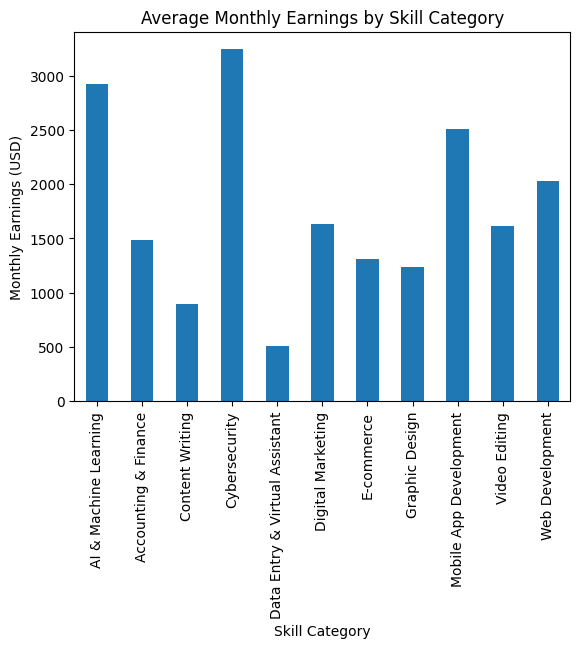

In [82]:
mk.groupby("skill_category")["monthly_earnings_usd"].mean().plot(
    kind="bar",
    title="Average Monthly Earnings by Skill Category",
    xlabel="Skill Category",
    ylabel="Monthly Earnings (USD)"
)

In [83]:
mk["hourly_rate_usd"].corr(mk["monthly_earnings_usd"])

np.float64(0.7705896908922152)

<Axes: title={'center': 'Hourly Rate vs Monthly Earnings'}, xlabel='Hourly Rate (USD)', ylabel='Monthly Earnings (USD)'>

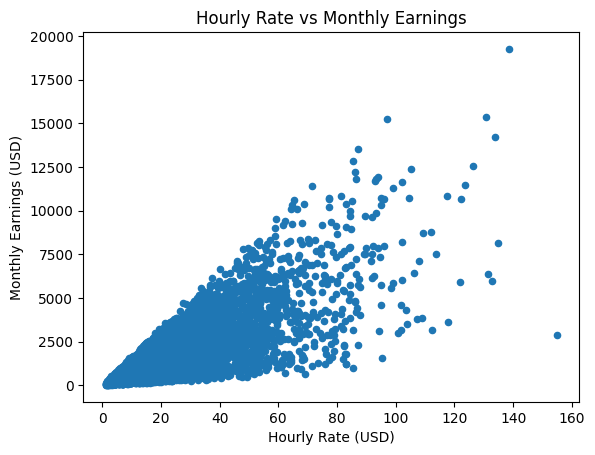

In [84]:
mk.plot(
    kind="scatter",
    x="hourly_rate_usd",
    y="monthly_earnings_usd",
    title="Hourly Rate vs Monthly Earnings",
    xlabel="Hourly Rate (USD)",
    ylabel="Monthly Earnings (USD)"
)

In [85]:
mk[["monthly_earnings_usd", "hourly_rate_usd", "experience_years", "jobs_completed"]].describe()

,monthly_earnings_usd,hourly_rate_usd,experience_years,jobs_completed
count,6000.000000,6000.000000,6000.000000,6000.000000
mean,1717.882667,23.898683,2.477867,98.842667
std,1737.318237,18.577619,1.878460,160.698035
min,16.000000,1.200000,0.300000,0.000000
25%,560.750000,10.600000,1.000000,6.000000
50%,1180.000000,19.000000,2.000000,34.000000
75%,2255.000000,31.500000,3.300000,119.000000
max,19252.000000,154.800000,10.900000,1292.000000


#Key Insights


*   The dataset contains 6,000 freelancer records across 36 columns.
*   The average monthly earning is approximately $1,717.88, while the median is $1,180.
*   Hourly rate and monthly earnings show a strong positive correlation of approximately 0.77.
*   Among experience groups, the 5–10 years group has the highest average monthly earnings in this dataset.
*   Upwork has a higher average monthly earning than Fiverr and Freelancer.com in this dataset.
*   Cybersecurity and AI & Machine Learning have relatively high average earnings among the listed skill categories.
*   English proficiency groups show differences in average earnings, with Fluent and Conversational having very similar averages.
*   The dataset contains no duplicate rows.
*   Missing values were identified and handled appropriately during data cleaning.











## Conclusion
This project analyzed a dataset of 6,000 freelancers using Python and Pandas. The data was cleaned by identifying missing values and checking for duplicate records. Exploratory data analysis was used to understand freelancer earnings, experience, platforms, education, skills, and other characteristics. Different visualizations helped present the main patterns clearly. A strong positive relationship was observed between hourly rate and monthly earnings, with a correlation of approximately 0.77. Overall, this project demonstrates how data cleaning, analysis, and visualization can be used to find meaningful patterns in freelancer data.
